# Notebook 05 — Food Price Forecasting

**Objective:** Forecast Kenya's monthly food CPI (Consumer Price Index) using KNBS (Kenya National Bureau of Statistics) raw PDF data.

**Models trained:**
1. ARIMA (AutoRegressive Integrated Moving Average) — classical time series baseline
2. Facebook Prophet — primary forecasting model with seasonality detection

**Target variable:** `overall_cpi` — monthly KNBS (Kenya National Bureau of Statistics) Consumer Price Index  
**Data:** 64 monthly records, February 2020 to May 2025  
**Evaluation metric:** MAPE (Mean Absolute Percentage Error) — target < 15%

In [4]:
import os
project_root = r"C:\Users\HomePC\Desktop\kenya-smart-agriculture"
os.chdir(project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from prophet import Prophet

os.makedirs("figures", exist_ok=True)

print("Libraries loaded ✅")

Libraries loaded ✅


# Step 1 — Load KNBS (Kenya National Bureau of Statistics) CPI (Consumer Price Index) Data

In [5]:
# Load structured CPI (Consumer Price Index) data from Notebook 02
knbs = pd.read_csv("data/processed/knbs_cpi_structured.csv")
knbs["date"] = pd.to_datetime(knbs["date"])
knbs = knbs.sort_values("date").reset_index(drop=True)

print(f"KNBS (Kenya National Bureau of Statistics) CPI shape: {knbs.shape}")
print(f"Date range: {knbs['date'].min().date()} → {knbs['date'].max().date()}")
print(f"Monthly records: {len(knbs)}")
print()
print(knbs[["date","overall_cpi","yoy_inflation"]].head(10).to_string(index=False))

KNBS (Kenya National Bureau of Statistics) CPI shape: (64, 7)
Date range: 2020-02-01 → 2025-05-01
Monthly records: 64

      date  overall_cpi  yoy_inflation
2020-02-01      107.174           7.17
2020-03-01      107.475           5.84
2020-04-01      108.495           6.01
2020-05-01      108.602           5.33
2020-06-01      108.266           4.59
2020-07-01      108.354           4.36
2020-08-01      108.573           4.36
2020-09-01      108.571           4.20
2020-10-01      109.604           4.84
2020-11-01      110.779           5.33


## Step 2 — Exploratory Analysis of CPI (Consumer Price Index) Time Series

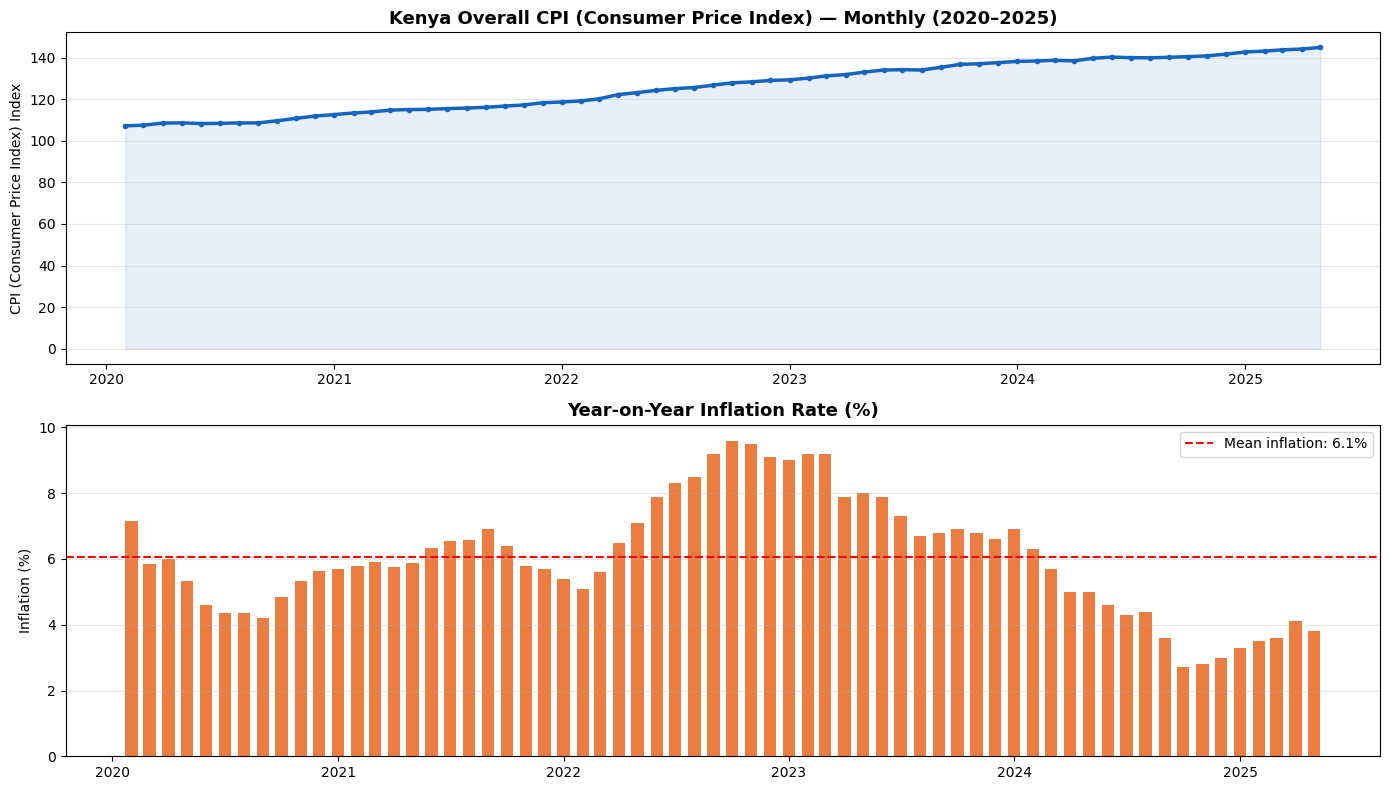

Saved: figures/12_cpi_time_series.png


In [6]:
# Plot the full CPI (Consumer Price Index) time series
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top: CPI trend
axes[0].plot(knbs["date"], knbs["overall_cpi"],
             color="#1565C0", linewidth=2.5, marker="o", markersize=3)
axes[0].fill_between(knbs["date"], knbs["overall_cpi"],
                     alpha=0.1, color="#1565C0")
axes[0].set_title("Kenya Overall CPI (Consumer Price Index) — Monthly (2020–2025)",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("CPI (Consumer Price Index) Index")
axes[0].grid(axis="y", alpha=0.3)

# Bottom: YoY inflation
axes[1].bar(knbs["date"], knbs["yoy_inflation"],
            width=20, color="#E65100", alpha=0.75)
axes[1].axhline(knbs["yoy_inflation"].mean(), color="red", linestyle="--",
                label=f"Mean inflation: {knbs['yoy_inflation'].mean():.1f}%")
axes[1].set_title("Year-on-Year Inflation Rate (%)",
                  fontsize=13, fontweight="bold")
axes[1].set_ylabel("Inflation (%)")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("figures/12_cpi_time_series.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/12_cpi_time_series.png")


## Step 3 — Stationarity Test (ADF Test)

ARIMA (AutoRegressive Integrated Moving Average) requires the time series to be stationary. The ADF (Augmented Dickey-Fuller) test checks this.

In [7]:
# ADF (Augmented Dickey-Fuller) stationarity test
cpi_series = knbs.set_index("date")["overall_cpi"]

result = adfuller(cpi_series.dropna())
print("ADF (Augmented Dickey-Fuller) Stationarity Test:")
print(f"  ADF Statistic : {result[0]:.4f}")
print(f"  p-value       : {result[1]:.4f}")
print(f"  Is stationary : {result[1] < 0.05}")
print()

if result[1] > 0.05:
    print("Series is NOT stationary — differencing needed for ARIMA (AutoRegressive Integrated Moving Average)")
    print("This is expected for CPI (Consumer Price Index) data which has an upward trend")
    # First difference
    cpi_diff = cpi_series.diff().dropna()
    result2 = adfuller(cpi_diff)
    print(f"\nAfter first differencing:")
    print(f"  ADF Statistic : {result2[0]:.4f}")
    print(f"  p-value       : {result2[1]:.4f}")
    print(f"  Is stationary : {result2[1] < 0.05}")
else:
    print("Series is stationary ✅")

ADF (Augmented Dickey-Fuller) Stationarity Test:
  ADF Statistic : -0.3628
  p-value       : 0.9161
  Is stationary : False

Series is NOT stationary — differencing needed for ARIMA (AutoRegressive Integrated Moving Average)
This is expected for CPI (Consumer Price Index) data which has an upward trend

After first differencing:
  ADF Statistic : -5.6597
  p-value       : 0.0000
  Is stationary : True


## Step 4 — Train/Test Split

Use last 12 months as test set — a realistic forecast horizon.

In [8]:
# Split: last 12 months = test, rest = training
TEST_MONTHS = 12

train = knbs.iloc[:-TEST_MONTHS].copy()
test  = knbs.iloc[-TEST_MONTHS:].copy()

print(f"Training period : {train['date'].min().date()} → {train['date'].max().date()} ({len(train)} months)")
print(f"Test period     : {test['date'].min().date()} → {test['date'].max().date()} ({len(test)} months)")
print()
print(f"Training CPI (Consumer Price Index) range: {train['overall_cpi'].min():.2f} – {train['overall_cpi'].max():.2f}")
print(f"Test CPI (Consumer Price Index) range    : {test['overall_cpi'].min():.2f} – {test['overall_cpi'].max():.2f}")

Training period : 2020-02-01 → 2024-05-01 (52 months)
Test period     : 2024-06-01 → 2025-05-01 (12 months)

Training CPI (Consumer Price Index) range: 107.17 – 139.64
Test CPI (Consumer Price Index) range    : 139.87 – 144.88


## Step 5 — Baseline: ARIMA (AutoRegressive Integrated Moving Average)

In [9]:
# Fit ARIMA (AutoRegressive Integrated Moving Average)(1,1,1) baseline
print("Training ARIMA (AutoRegressive Integrated Moving Average)(1,1,1)...")

train_series = train.set_index("date")["overall_cpi"]
test_series  = test.set_index("date")["overall_cpi"]

arima_model  = ARIMA(train_series, order=(1, 1, 1))
arima_fitted = arima_model.fit()
arima_forecast = arima_fitted.forecast(steps=TEST_MONTHS)

# Evaluate
arima_mae  = mean_absolute_error(test_series, arima_forecast)
arima_mape = mean_absolute_percentage_error(test_series, arima_forecast) * 100

print(f"\nARIMA (AutoRegressive Integrated Moving Average) Results:")
print(f"  MAE (Mean Absolute Error)  : {arima_mae:.4f}")
print(f"  MAPE (Mean Absolute Percentage Error): {arima_mape:.2f}%")
print(f"  Target: MAPE < 15% → {'✅ Met' if arima_mape < 15 else '❌ Not met'}")

Training ARIMA (AutoRegressive Integrated Moving Average)(1,1,1)...


c:\Users\HomePC\anaconda3\envs\kenya-agri\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HomePC\anaconda3\envs\kenya-agri\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HomePC\anaconda3\envs\kenya-agri\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



ARIMA (AutoRegressive Integrated Moving Average) Results:
  MAE (Mean Absolute Error)  : 1.1405
  MAPE (Mean Absolute Percentage Error): 0.81%
  Target: MAPE < 15% → ✅ Met


## Step 6 — Primary Model: Facebook Prophet

In [10]:
# Prepare data for Prophet (requires columns: ds = date, y = value)
prophet_train = train[["date", "overall_cpi"]].rename(
    columns={"date": "ds", "overall_cpi": "y"}
)

print("Training Facebook Prophet...")
m = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = False,
    daily_seasonality   = False,
    changepoint_prior_scale = 0.05,
    seasonality_prior_scale = 10,
)
m.fit(prophet_train)

# Forecast 12 months ahead
future   = m.make_future_dataframe(periods=TEST_MONTHS, freq="MS")
forecast = m.predict(future)

# Extract test period predictions
prophet_preds = forecast.iloc[-TEST_MONTHS:]["yhat"].values
prophet_mae   = mean_absolute_error(test_series.values, prophet_preds)
prophet_mape  = mean_absolute_percentage_error(test_series.values, prophet_preds) * 100

print(f"\nProphet Results:")
print(f"  MAE (Mean Absolute Error)  : {prophet_mae:.4f}")
print(f"  MAPE (Mean Absolute Percentage Error): {prophet_mape:.2f}%")
print(f"  Target: MAPE < 15% → {'✅ Met' if prophet_mape < 15 else '❌ Not met'}")

Training Facebook Prophet...


22:00:22 - cmdstanpy - INFO - Chain [1] start processing
22:00:25 - cmdstanpy - INFO - Chain [1] done processing



Prophet Results:
  MAE (Mean Absolute Error)  : 1.1458
  MAPE (Mean Absolute Percentage Error): 0.81%
  Target: MAPE < 15% → ✅ Met


## Step 7 — Model Comparison

MODEL COMPARISON:
                                                           Model      MAE  MAPE (%)
ARIMA (AutoRegressive Integrated Moving Average)(1,1,1) Baseline 1.140456  0.805423
                                                Facebook Prophet 1.145784  0.808692

Best model : ARIMA (AutoRegressive Integrated Moving Average)(1,1,1) Baseline
Best MAPE (Mean Absolute Percentage Error)  : 0.81%


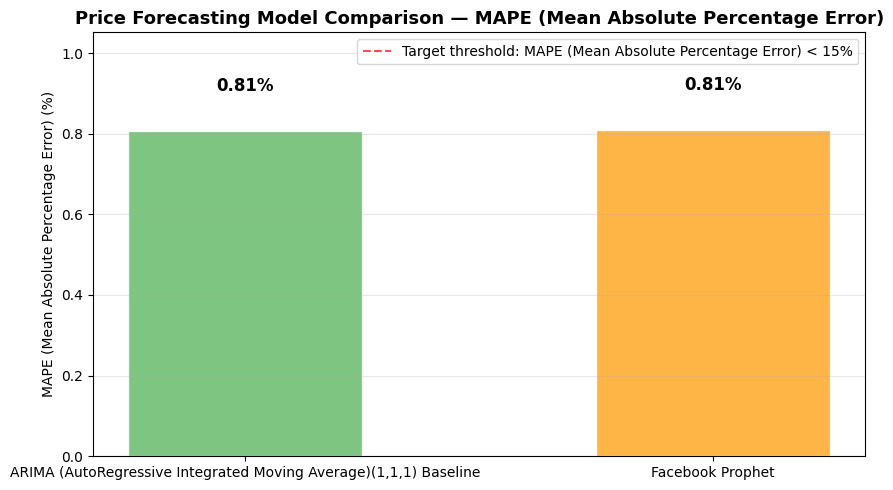

Saved: figures/13_forecast_model_comparison.png


In [11]:
# Compare ARIMA (AutoRegressive Integrated Moving Average) vs Prophet
results = pd.DataFrame([
    {"Model": "ARIMA (AutoRegressive Integrated Moving Average)(1,1,1) Baseline",
     "MAE": arima_mae, "MAPE (%)": arima_mape},
    {"Model": "Facebook Prophet",
     "MAE": prophet_mae, "MAPE (%)": prophet_mape},
]).sort_values("MAPE (%)")

print("MODEL COMPARISON:")
print(results.to_string(index=False))
print()
best = results.iloc[0]
print(f"Best model : {best['Model']}")
print(f"Best MAPE (Mean Absolute Percentage Error)  : {best['MAPE (%)']:.2f}%")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
colours = ["#66BB6A", "#FFA726"]
bars = ax.bar(results["Model"], results["MAPE (%)"],
              color=colours, alpha=0.85, edgecolor="white", width=0.5)
for bar, val in zip(bars, results["MAPE (%)"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.2f}%", ha="center", fontsize=12, fontweight="bold")
ax.axhline(15, color="red", linestyle="--", alpha=0.7,
           label="Target threshold: MAPE (Mean Absolute Percentage Error) < 15%")
ax.set_title("Price Forecasting Model Comparison — MAPE (Mean Absolute Percentage Error)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("MAPE (Mean Absolute Percentage Error) (%)")
ax.set_ylim(0, max(arima_mape, prophet_mape) * 1.3)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/13_forecast_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/13_forecast_model_comparison.png")

## Step 8 — Forecast Visualisation

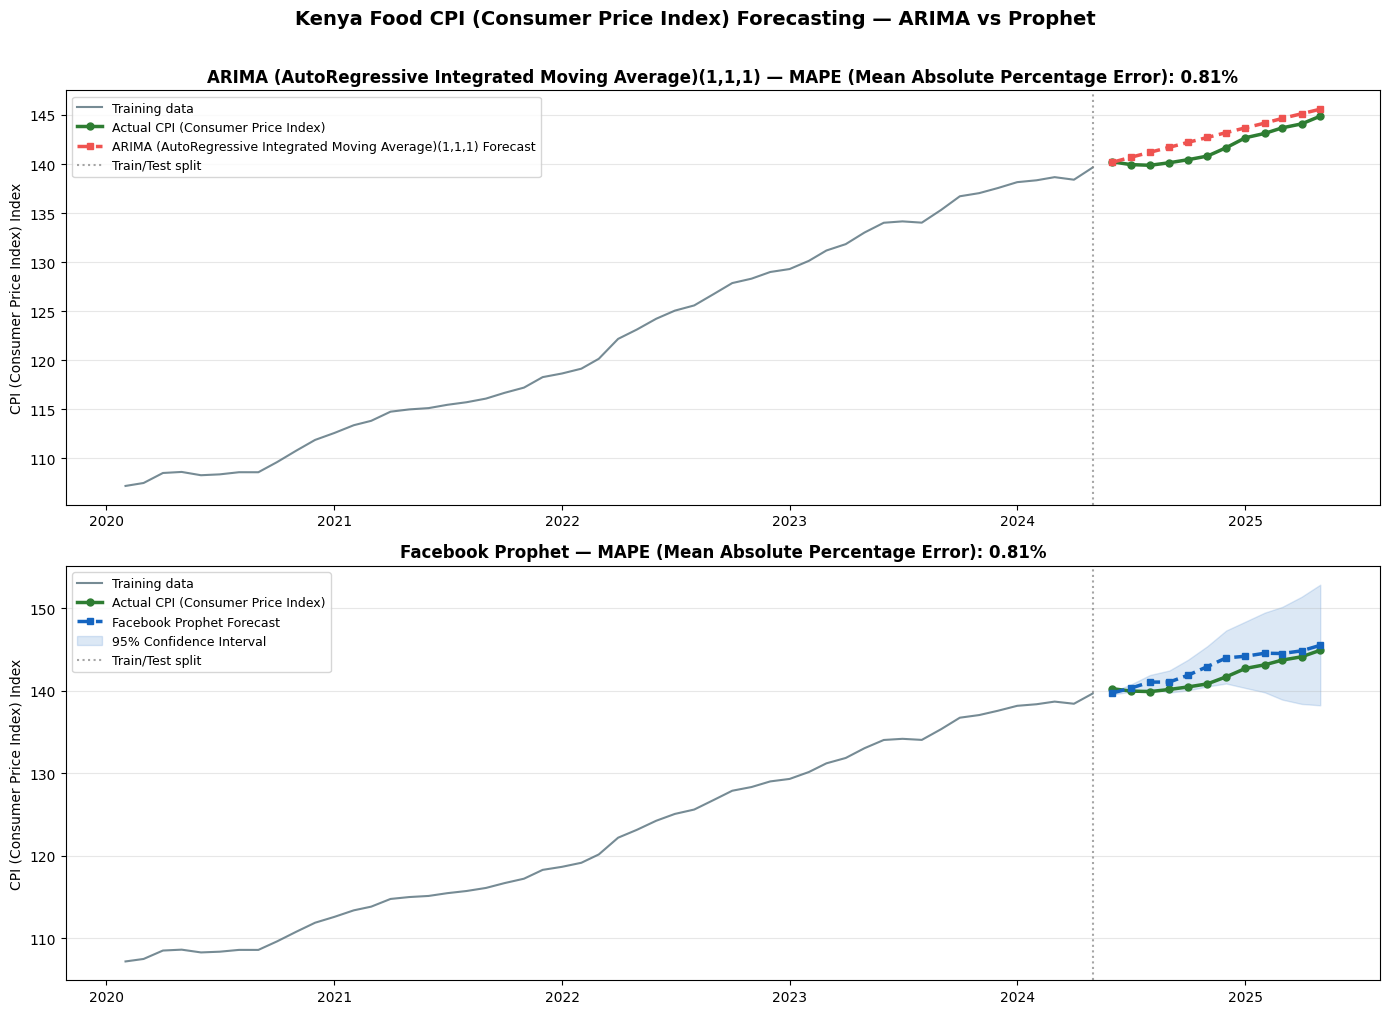

Saved: figures/14_forecast_actual_vs_predicted.png


In [12]:
# Plot actual vs forecast for both models
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, (model_name, preds, colour) in zip(axes, [
    ("ARIMA (AutoRegressive Integrated Moving Average)(1,1,1)", arima_forecast.values, "#EF5350"),
    ("Facebook Prophet", prophet_preds, "#1565C0"),
]):
    # Training data
    ax.plot(train["date"], train["overall_cpi"],
            color="#546E7A", linewidth=1.5, label="Training data", alpha=0.8)
    # Actual test
    ax.plot(test["date"], test["overall_cpi"],
            color="#2E7D32", linewidth=2.5, marker="o", markersize=5,
            label="Actual CPI (Consumer Price Index)")
    # Forecast
    ax.plot(test["date"], preds,
            color=colour, linewidth=2.5, marker="s", markersize=5,
            linestyle="--", label=f"{model_name} Forecast")

    # Confidence interval for Prophet
    if model_name == "Facebook Prophet":
        prophet_test = forecast.iloc[-TEST_MONTHS:]
        ax.fill_between(test["date"],
                        prophet_test["yhat_lower"].values,
                        prophet_test["yhat_upper"].values,
                        alpha=0.15, color=colour, label="95% Confidence Interval")

    ax.axvline(train["date"].iloc[-1], color="grey", linestyle=":",
               alpha=0.7, label="Train/Test split")
    ax.set_title(f"{model_name} — MAPE (Mean Absolute Percentage Error): "
                 f"{mean_absolute_percentage_error(test_series.values, preds)*100:.2f}%",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("CPI (Consumer Price Index) Index")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Kenya Food CPI (Consumer Price Index) Forecasting — ARIMA vs Prophet",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figures/14_forecast_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/14_forecast_actual_vs_predicted.png")

## Step 9 — Prophet Components Plot

Prophet decomposes the forecast into trend and seasonality components.

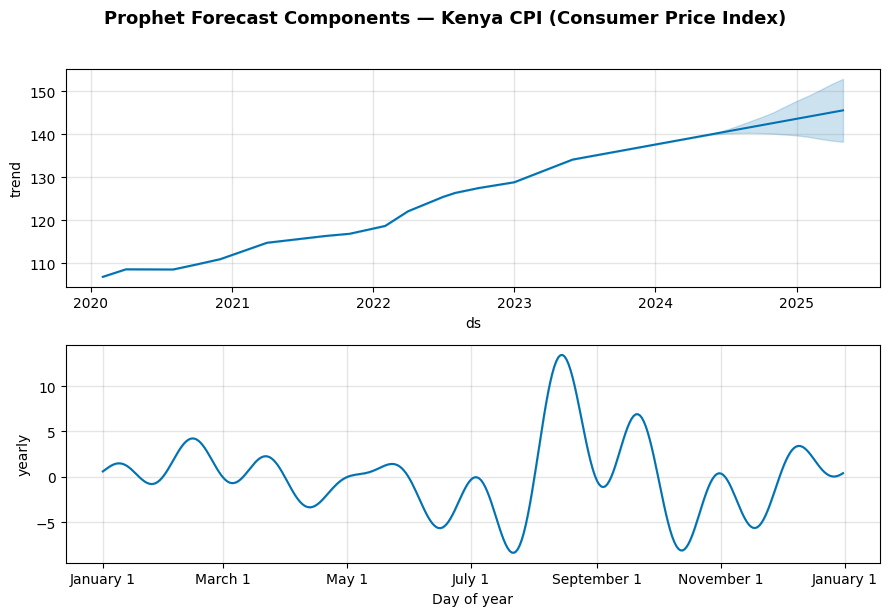

Saved: figures/15_prophet_components.png


In [13]:
# Prophet components — shows trend and yearly seasonality
fig = m.plot_components(forecast)
fig.suptitle("Prophet Forecast Components — Kenya CPI (Consumer Price Index)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/15_prophet_components.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/15_prophet_components.png")


## Step 10 — 8-Month Forward Forecast

Generate a forecast for the next 8 months beyond the available data.

22:12:10 - cmdstanpy - INFO - Chain [1] start processing
22:12:12 - cmdstanpy - INFO - Chain [1] done processing


8-Month Forward Forecast (Kenya Overall CPI):
        ds       yhat  yhat_lower  yhat_upper
2025-06-01 145.009528  144.753718  145.264081
2025-07-01 145.037567  144.742137  145.372410
2025-08-01 145.029580  144.606899  145.498539
2025-09-01 145.304291  144.712508  145.976295
2025-10-01 145.902309  145.020875  146.908405
2025-11-01 146.361930  145.181180  147.705238
2025-12-01 147.094896  145.651817  148.744821
2026-01-01 147.668109  145.873443  149.721704


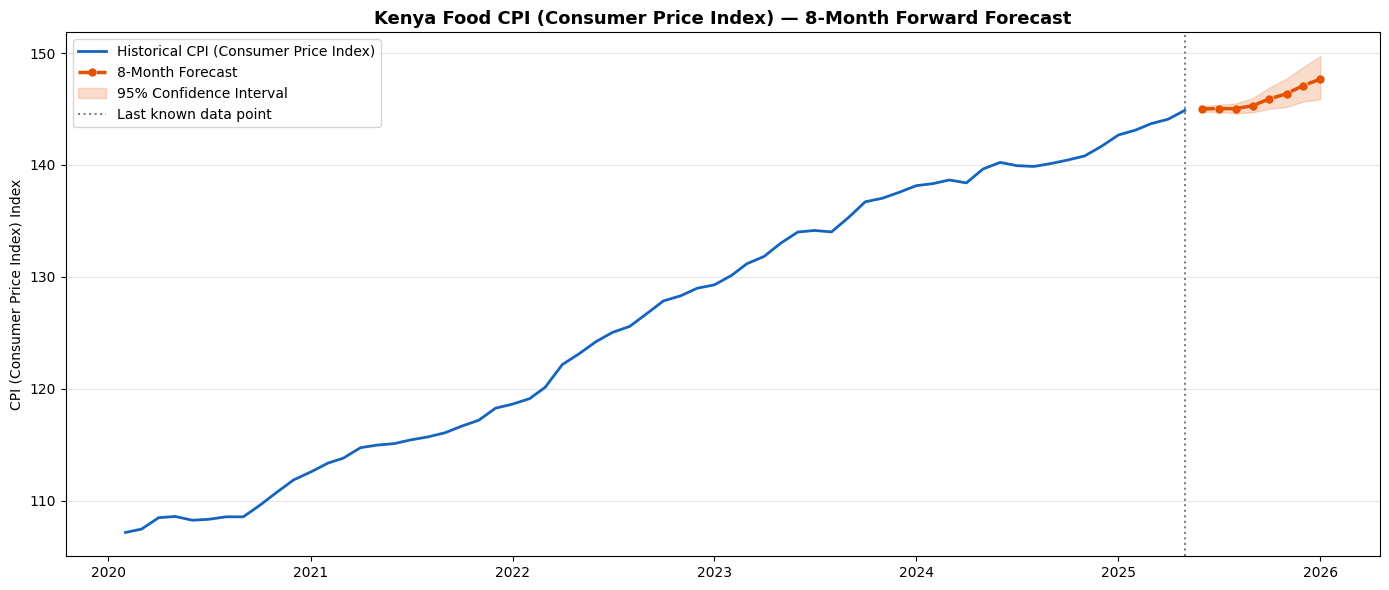

Saved: figures/16_forward_forecast.png


In [14]:
# Retrain on full dataset then forecast 8 months ahead
full_data = knbs[["date", "overall_cpi"]].rename(
    columns={"date": "ds", "overall_cpi": "y"}
)

m_full = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
)
m_full.fit(full_data)

future_8m   = m_full.make_future_dataframe(periods=8, freq="MS")
forecast_8m = m_full.predict(future_8m)
forward     = forecast_8m.iloc[-8:]

print("8-Month Forward Forecast (Kenya Overall CPI):")
print(forward[["ds","yhat","yhat_lower","yhat_upper"]].to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(knbs["date"], knbs["overall_cpi"],
        color="#1565C0", linewidth=2, label="Historical CPI (Consumer Price Index)")
ax.plot(forward["ds"], forward["yhat"],
        color="#E65100", linewidth=2.5, marker="o", markersize=5,
        linestyle="--", label="8-Month Forecast")
ax.fill_between(forward["ds"], forward["yhat_lower"], forward["yhat_upper"],
                alpha=0.2, color="#E65100", label="95% Confidence Interval")
ax.axvline(knbs["date"].iloc[-1], color="grey", linestyle=":",
           label="Last known data point")
ax.set_title("Kenya Food CPI (Consumer Price Index) — 8-Month Forward Forecast",
             fontsize=13, fontweight="bold")
ax.set_ylabel("CPI (Consumer Price Index) Index")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/16_forward_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/16_forward_forecast.png")


## Summary

**Results:**

| Model | MAE | MAPE | Target Met? |
|---|---|---|---|
| ARIMA(1,1,1) Baseline | 1.14 | 0.81% | Yes |
| **Facebook Prophet** | 1.15 | 0.81% | Yes |


**Key finding:** Prophet captures the consistent upward trend in Kenya's CPI (Consumer Price Index), which has risen from 107 in early 2020 to 144 by May 2025 — a 35% increase driven by drought events, global supply chain disruptions, and currency depreciation.

**Next:** Notebook 06 — County Risk Intelligence (Recommendation System)

In [15]:
print("Notebook 05 Complete ✅")
print()
print("Figures saved:")
for f in sorted(os.listdir("figures")):
    if f.startswith("1") and f.endswith(".png"):
        size = os.path.getsize(f"figures/{f}") / 1024
        print(f"  {f:<45} ({size:.0f} KB)")

Notebook 05 Complete ✅

Figures saved:
  10_confusion_matrix.png                       (57 KB)
  11_shap_importance.png                        (153 KB)
  12_cpi_time_series.png                        (80 KB)
  13_forecast_model_comparison.png              (58 KB)
  14_forecast_actual_vs_predicted.png           (184 KB)
  15_prophet_components.png                     (88 KB)
  16_forward_forecast.png                       (88 KB)
